In [1]:
library(ggplot2)
library(readr)
library(corrplot)
library(FactoMineR)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'corrplot' was built under R version 4.5.3"
corrplot 0.95 loaded

Warning message:
"package 'FactoMineR' was built under R version 4.5.3"


In [2]:
europe <- read.table(
  "C:/Users/Julien ANTOGNELLI/Documents/ESGI/Maths/MathsForR/data/Donnees Europe.txt",
  header = TRUE,   # 1ère ligne = noms des colonnes
  row.names = 1    # 1ère colonne = noms des lignes (at, be, cy...)
)

# Introduction au jeu de données

In [3]:
head(europe)

,benev,chom,depedu,depsoc,devel,pib,pvap,pvav,trvpv
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
at,60,4.7,5.45,29.1,0.944,128.8,12,24,6
be,37,8.1,5.99,29.3,0.945,112.3,15,28,3
cy,23,4.6,6.71,17.8,0.903,93.2,16,22,6
cz,33,7.7,4.42,19.6,0.885,79.4,10,21,3
de,52,9.1,4.60,29.5,0.932,113.6,13,24,4
dk,49,4.9,8.47,30.7,0.943,126.7,12,31,4


## Graphes de couples de variables

### Couple `chom`et `depsoc`

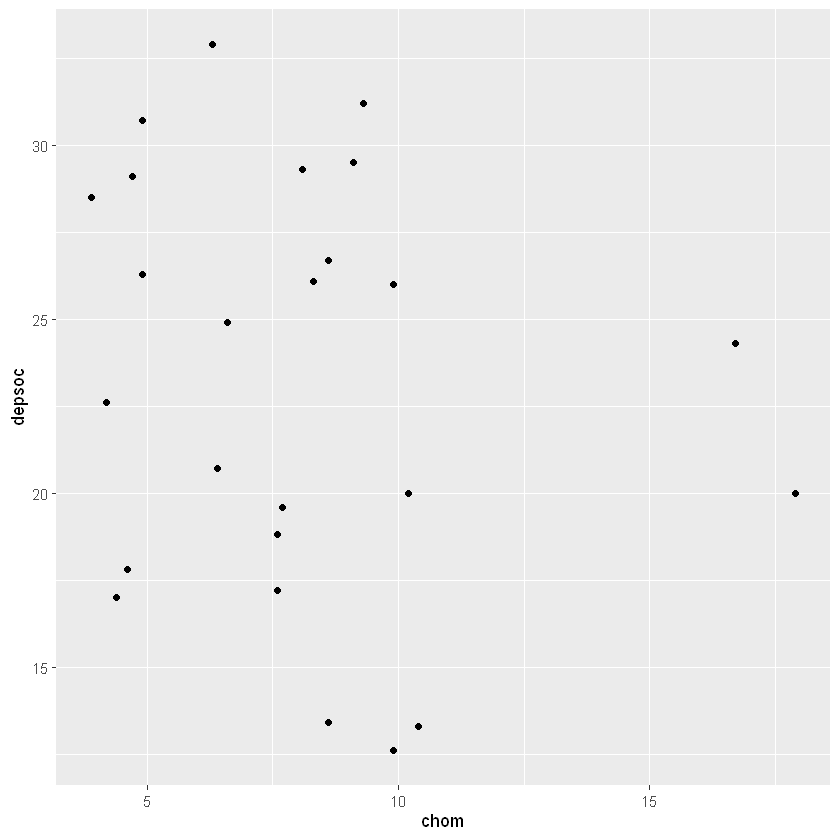

In [4]:
ggplot(europe, aes(x = chom, y = depsoc)) +
  geom_point() +
  labs(x = "chom",
       y = "depsoc")


### Couple `PIB`et `devel`

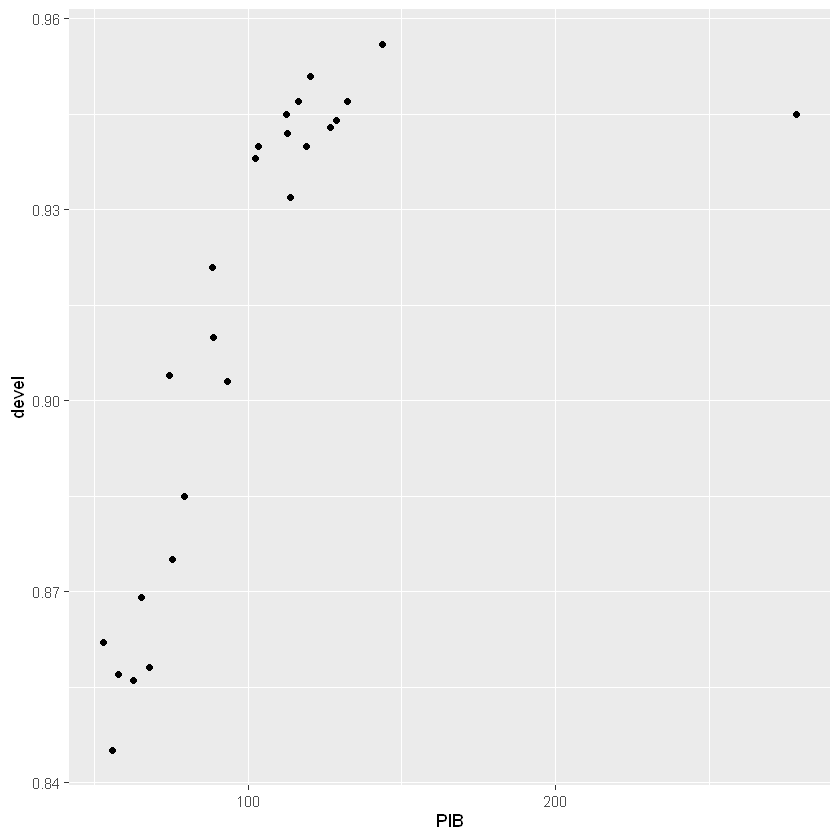

In [ ]:
ggplot(europe, aes(x = pib, y = devel)) +
  geom_point() +
  labs(x = "PIB",
       y = "devel")

### Couple `benev`et `pvapr`

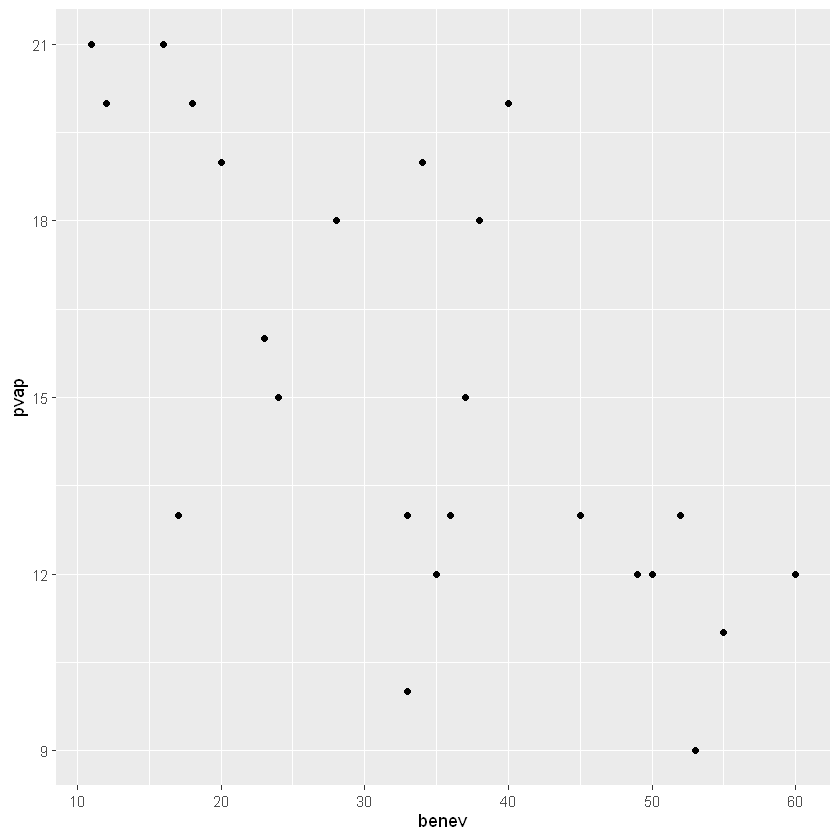

In [13]:
ggplot(europe, aes(x = benev, y = pvap)) +
  geom_point() +
  labs(x = "benev",
       y = "pvap")

**Interprétation**

- (chom, depsoc) -> nuage dispersé, pas de tendance
- (PIB, devel) -> tendance croissante nette, mais un point isolé avec un très fort PIB
- (benev, pvap) -> tendance négative modérée

## Matrice des corrélations des variables

In [32]:
cor_mat <- round(cor(europe, method = "pearson"), 2)
cor_mat
write.csv(cor_mat, file = "./graphs_&_tables/corr_matrix.csv", row.names = TRUE)

,benev,chom,depedu,depsoc,devel,pib,pvap,pvav,trvpv
benev,1.00,-0.41,0.28,0.58,0.62,0.56,-0.71,0.02,-0.63
chom,-0.41,1.00,-0.28,-0.19,-0.56,-0.55,0.32,-0.07,0.46
depedu,0.28,-0.28,1.00,0.34,0.23,-0.05,-0.36,0.50,-0.45
depsoc,0.58,-0.19,0.34,1.00,0.70,0.36,-0.50,0.14,-0.23
devel,0.62,-0.56,0.23,0.70,1.00,0.69,-0.30,0.23,-0.35
pib,0.56,-0.55,-0.05,0.36,0.69,1.00,-0.32,0.02,-0.18
pvap,-0.71,0.32,-0.36,-0.50,-0.30,-0.32,1.00,0.16,0.66
pvav,0.02,-0.07,0.50,0.14,0.23,0.02,0.16,1.00,-0.09
trvpv,-0.63,0.46,-0.45,-0.23,-0.35,-0.18,0.66,-0.09,1.00


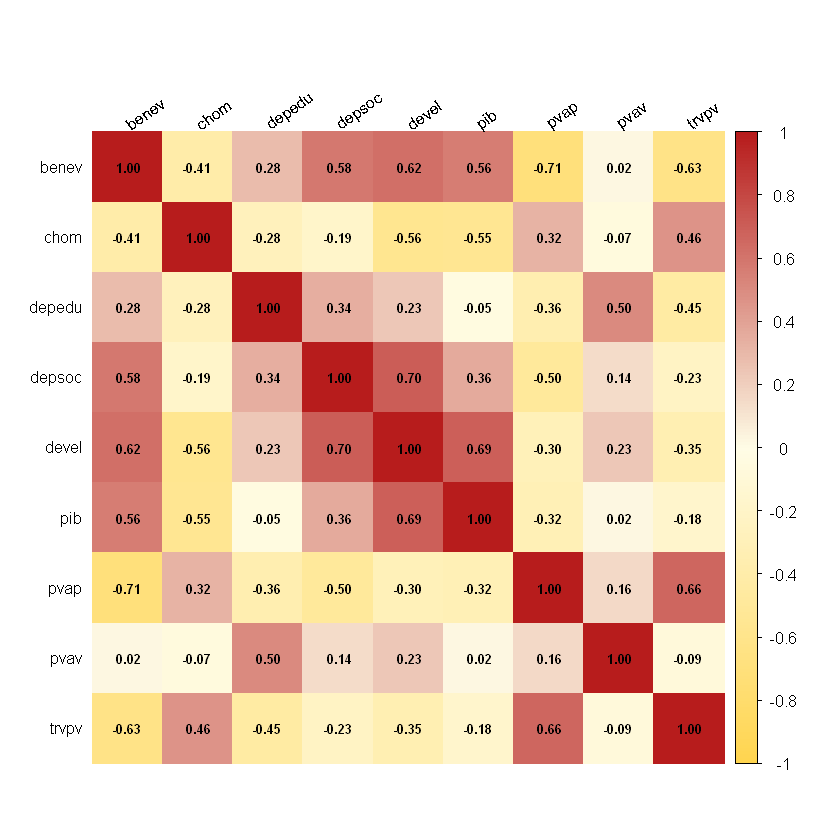

In [33]:
corrplot(cor_mat,
         method = "color",
         type = "full",
         diag = TRUE,
         col = colorRampPalette(c("#FFD54F", "#FFFDE7", "#B71C1C"))(200),
         tl.col = "black",
         tl.cex = 0.8,
         tl.srt = 35,
         addCoef.col = "black",
         number.cex = 0.65,
         mar = c(1, 1, 2, 1)
         )

**Interprétation**

- Le plus corrélé -> (vief, vieh) avec un coefficient de corrélation de 0,91 

- Le moins corrélé -> (chom, depsoc) avec -0,19

- Le plus opposé -> (satfam, ssabri) avec -0,64 

Warning message:
"package 'ggrepel' was built under R version 4.5.3"


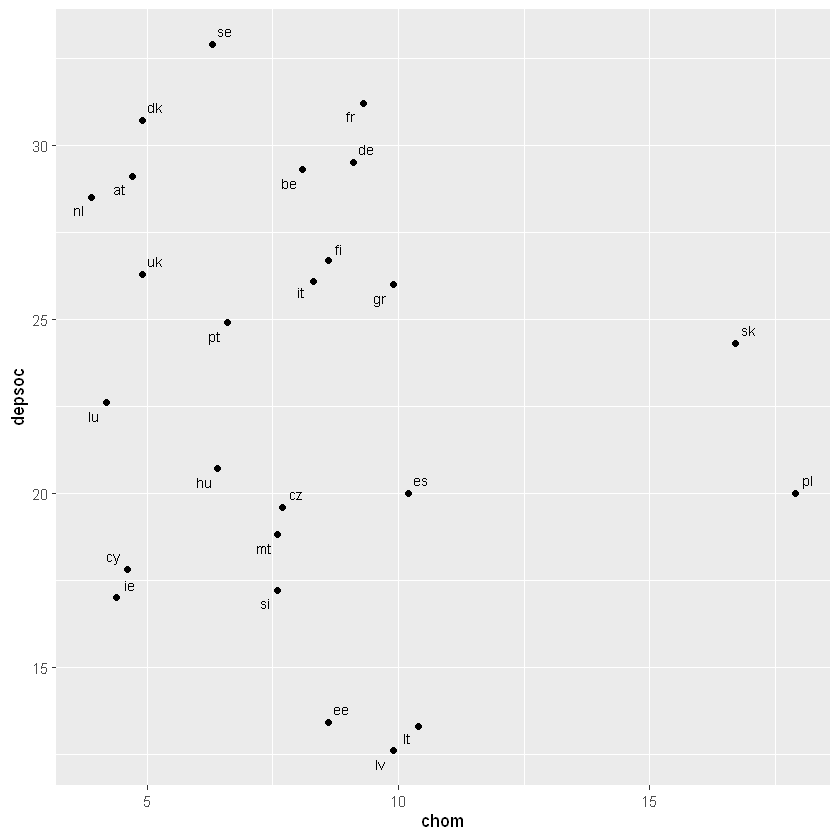

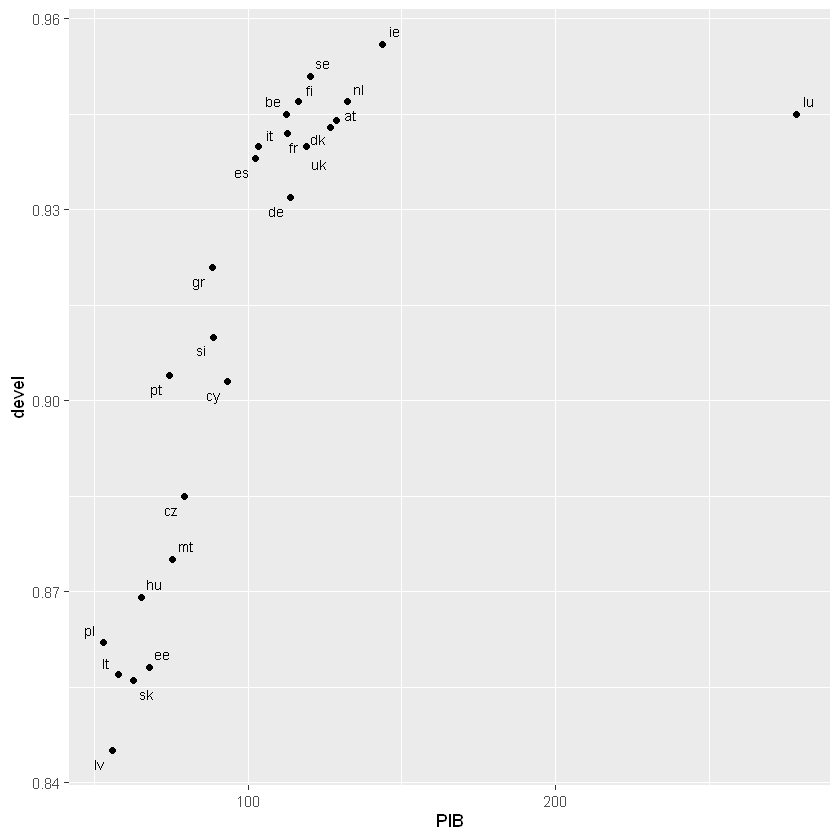

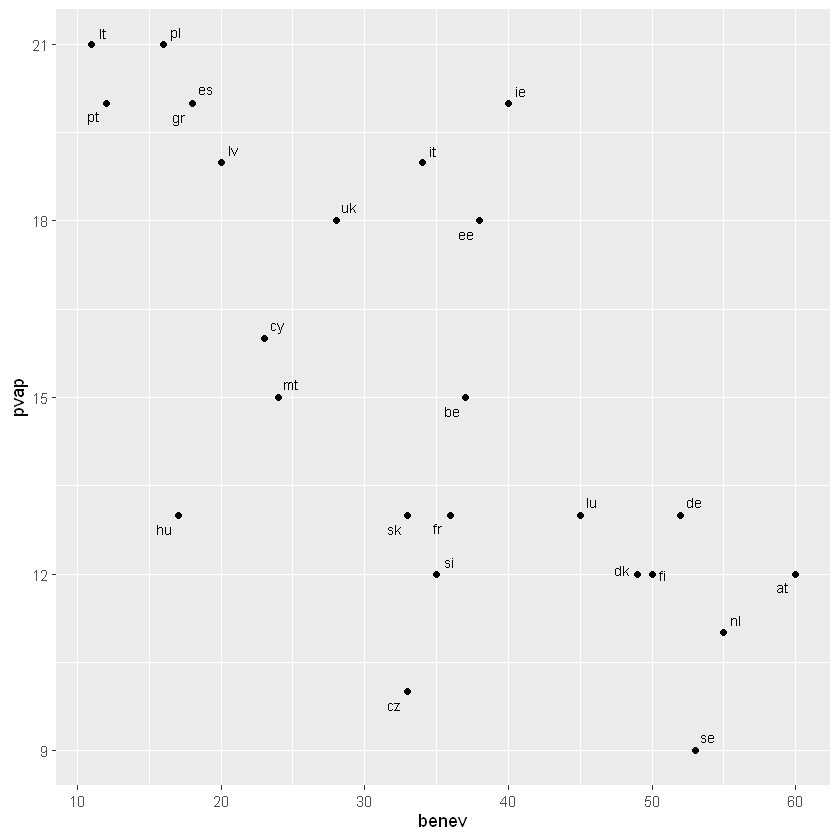

In [20]:
library(ggrepel)

# Graphe chom / depsoc
ggplot(europe, aes(x = chom, y = depsoc, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "chom", y = "depsoc")

# Graphe pib / devel
ggplot(europe, aes(x = pib, y = devel, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "PIB", y = "devel")

# Graphe benev / pvap
ggplot(europe, aes(x = benev, y = pvap, label = rownames(europe))) +
  geom_point() +
  geom_text_repel(size = 3) +
  labs(x = "benev", y = "pvap")

**Détection d'individus anormaux**

Couple `(chom, depsoc)` -> 
- ee, lv et lt se détachent nettement en bas du graphe
- sk et pl sont isolés à droite 

**donc** : ces outliers tirent dans des directions contradictiones et s'annulent mutuellement ce qui fait chuter la corrélation à -0.19

Couple `(PIB, devel)`->
- lu est complètement isolé à droite
- ie en haut à gauche a l'IDH le plus élevé avec un PIB dans la moyenne
- lv en bas à gauche: PIB et IDH tous les deux faibles

**donc** lu déforme l'axe horizontal et affaiblit le coefficient, car son PIB n'est pas proportionnellement reflété dans son IDH

# Première ACP

### Pré-traitement du df avant manipulations

In [22]:
# conversion requise par FactoMineR
europe <- as.data.frame(europe)

# Supprimer la 1re colonne du tableau de données
europe_num <- europe[, -1]

## Centrer et réduire les données

In [23]:
# scale.unit = TRUE centre et réduit les données(ACP normée)
# ncp = 4 indique que l'on souhaite conserver les 4 premières composantes principales
res.pca <- PCA(europe_num, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales

In [24]:
# $eig renvoie les valeurs propres, les pourcentages de variance expliquée et les pourcentages de variance cumulée
variances_cp <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca$eig[1:4, 1], 2)
)

variances_cp
write.csv(variances_cp, file = "./graphs_&_tables/variances_cp.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,3.36
comp 2,Dim.2,1.46
comp 3,Dim.3,1.25
comp 4,Dim.4,0.91


## Tableau de corrélation des variables

In [25]:
corr_variables <- round(res.pca$var$cor[, 1:4], 2)
corr_variables
write.csv(corr_variables, file = "./graphs_&_tables/corr_variables.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
chom,-0.70,0.19,-0.04,0.58
depedu,0.53,0.74,-0.04,-0.02
depsoc,0.70,-0.02,0.14,0.66
devel,0.83,-0.23,0.39,0.10
pib,0.65,-0.56,0.29,-0.13
pvap,-0.69,0.01,0.61,-0.21
pvav,0.24,0.67,0.61,-0.11
trvpv,-0.68,-0.24,0.50,0.25


Coordonées des variables => corrélations variable / composante

Toutes les variables ont une forte corrélation avec Dim1 -> effet de taille

## Coordonées des individus sur les axes

In [26]:
coord_individus <- round(res.pca$ind$coord[, 1:4], 2)
coord_individus
write.csv(coord_individus, file = "./graphs_&_tables/coord_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,1.74,-0.81,-0.28,0.31
be,1.65,0.74,0.22,0.39
cy,0.10,0.23,-0.91,-1.22
cz,-0.17,-0.74,-2.58,-0.31
de,0.92,-0.75,-0.65,0.93
dk,3.19,2.36,0.49,0.06
ee,-1.97,0.32,-0.93,-1.24
es,-1.41,-1.18,1.09,0.20
fi,1.91,0.97,-0.24,0.34
fr,1.42,0.21,-0.08,1.19


## Contribution des individus aux axes 

In [27]:
contrib_individus <- round(res.pca$ind$contrib[, 1:4], 2)
contrib_individus
write.csv(contrib_individus, file = "./graphs_&_tables/contrib_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,3.58,1.81,0.25,0.43
be,3.25,1.48,0.16,0.67
cy,0.01,0.15,2.67,6.55
cz,0.03,1.50,21.36,0.42
de,1.00,1.54,1.37,3.77
dk,12.13,15.19,0.76,0.01
ee,4.60,0.27,2.78,6.70
es,2.37,3.83,3.82,0.17
fi,4.34,2.56,0.19,0.51
fr,2.40,0.12,0.02,6.21


## Faire une représentation graphique des valeurs propres

In [28]:
png("./graphs_&_tables/valeurs_propres.png", width = 800, height = 600, res = 120)

# récupérer les valeurs propres
vp <- res.pca$eig[, 1]

plot(1:length(vp), vp, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres")

# ligne du critère de Kaiser
abline(h = 1, col = "red", lty = 2)

legend("topright",
       legend = expression("Critère de Kaiser (" * lambda == 1 * ")"),
       col = "red",
       lty = 2,
       lwd = 1,
       bty = "n")

dev.off()

pdf 
  2

Selon la règle de Kaiser (valeur propre > 1, ligne rouge) :

2 composantes principales sont à retenir: l'axe 1 (~8.5) et l'axe 2 (~1.2) sont au-dessus du seuil, l'axe 3 passe déjà en dessous.

## Pourcentage d'inertie totale expliquée par le sous-espace principal correspondant

In [29]:
# Extraction des lignes où la valeur propre est > 1, puis arrondi à 2 décimales
res_filtre <- round(res.pca$eig[res.pca$eig[, 1] > 1, ], 2)

# Affichage du résultat
res_filtre

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,3.36,42.01,42.01
comp 2,1.46,18.30,60.31
comp 3,1.25,15.63,75.94


2 axes sont retenus, le 1 et 2 et expliquent à eux seuls 73.91% de l'inertie

## Tracer le cercle de corrélation des variables

pdf 
  2

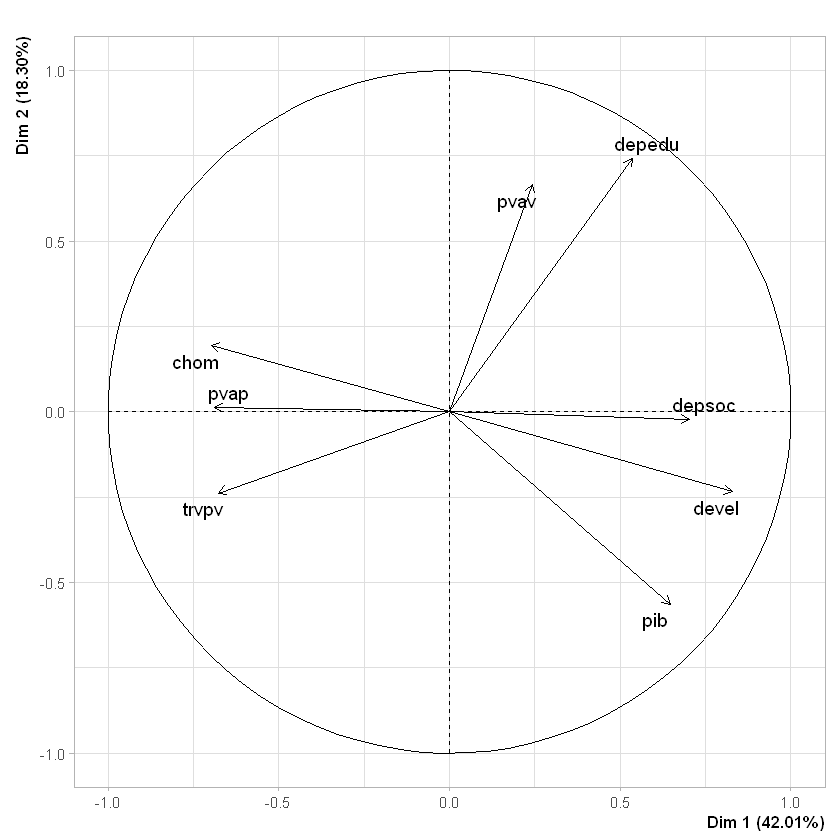

In [30]:
png("./graphs_&_tables/cercle_correlation.png", width = 800, height = 800, res = 120)

# choix = "var" indique que l'on souhaite afficher les variables
plot(res.pca, choix = "var", axes = c(1, 2), title = " ")

dev.off()

# Affichage
plot(res.pca, choix = "var", axes = c(1, 2), title="")

In [31]:
corr_vars <- round(res.pca$var$coord[, 1:2], 2)

axe_dominant <- apply(corr_vars, 1, function(x) {
  if (abs(x[1]) > abs(x[2])) {
    paste0("Dim 1 (", ifelse(x[1] >= 0, "+", "-"), ")")
  } else if (abs(x[2]) > abs(x[1])) {
    paste0("Dim 2 (", ifelse(x[2] >= 0, "+", "-"), ")")
  } else {
    "Dim 1 et 2"
  }
})

tab_axes <- data.frame(
  Variable = rownames(corr_vars),
  `Axe dominant` = axe_dominant,
  `r (Dim 1)` = corr_vars[, 1],
  `r (Dim 2)` = corr_vars[, 2],
  row.names = NULL,
  check.names = FALSE
)

tab_axes
write.csv(tab_axes, file = "./graphs_&_tables/axes_variables.csv", row.names = FALSE)

Variable,Axe dominant,r (Dim 1),r (Dim 2)
<chr>,<chr>,<dbl>,<dbl>
chom,Dim 1 (-),-0.70,0.19
depedu,Dim 2 (+),0.53,0.74
depsoc,Dim 1 (+),0.70,-0.02
devel,Dim 1 (+),0.83,-0.23
pib,Dim 1 (+),0.65,-0.56
pvap,Dim 1 (-),-0.69,0.01
pvav,Dim 2 (+),0.24,0.67
trvpv,Dim 1 (-),-0.68,-0.24


Toutes les variables sont dominées par Dim1, aucune n'est exclusive à Dim2 ce qui confirme que l'axe 2 est secondaire et difficile à interpréter seul 

**effet de taille important**